In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import glob


In [25]:

# Use a raw string (r"...") so Windows backslashes are not treated as escape characters
file_path = r"G:\ASCII-ICE\1132_026560_20050101_014337_20050101_021752_full.pkl"

# Load the DataFrame
data = pd.read_pickle(file_path)
df = data
# Inspect the loaded data
print("Shape:", df.shape)
display(df.head())


Shape: (501, 7)


,datetime,geoc_lat,geoc_long,local_time,altitude,spectrum0,spectrum1
0,2005-01-01 01:43:36.606,70.9423,152.5599,11.8975,711.242,"[2.3874683380126953, 2.3458333015441895, 2.214...","[2.4266841411590576, 2.3458333015441895, 2.097..."
1,2005-01-01 01:43:40.702,70.7172,152.2218,11.8761,711.251,"[2.0737428665161133, 1.7183823585510254, 1.352...","[2.2306056022644043, 2.1889705657958984, 2.018..."
2,2005-01-01 01:43:44.798,70.4921,151.8836,11.8547,711.260,"[1.6815860271453857, 1.5223039388656616, 1.352...","[2.8972723484039307, 2.581127405166626, 2.0580..."
3,2005-01-01 01:43:48.894,70.2670,151.5454,11.8333,711.269,"[2.7011938095092773, 2.5419118404388428, 2.097...","[2.5443310737609863, 2.3850491046905518, 2.175..."
4,2005-01-01 01:43:52.990,70.0418,151.2073,11.8119,711.278,"[1.7208017110824585, 1.6791666746139526, 1.352...","[1.3678605556488037, 1.2085784673690796, 1.038..."


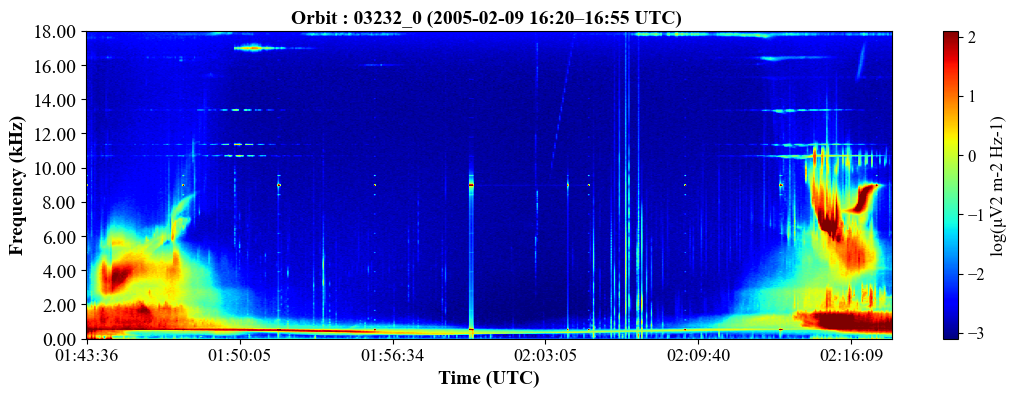

(501, 1024)

In [26]:

import numpy as  np
import pandas as pd
import os
import matplotlib.pyplot as plt
import scipy as sp
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Set Cambria as default font
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

rcParams['font.size'] = 12    

# data1 = pd.read_pickle('F:\\ASCII_1132\\28-02-2010.pkl')
sp_01 =data['spectrum1'].values
sp_01 = np.array([np.array(x) for x in sp_01])
sp_01 = sp_01.astype(float)
sp_0 =data['spectrum0'].values
sp_0 = np.array([np.array(x) for x in sp_0])
sp_0 = sp_0.astype(float)



# min_freq = 19.035
# max_freq = 18000
#freq_list = np.logspace(np.log10(min_freq), np.log10(max_freq),sp_0.shape[0])
min_freq = 0
max_freq = 18
# Generate a list of frequencies using numpy
freq_list = np.linspace(min_freq, max_freq,10)
freq_list = ["%.2f" % z for z in freq_list]

fig, ax = plt.subplots(figsize=(13,4))
im = ax.imshow(sp_01.T, origin='lower', aspect='auto', cmap='jet',vmax= 2.1, vmin = -3.1)
im = ax.imshow(sp_0.T, origin='lower', aspect='auto', cmap='jet',vmax= 2.1, vmin = -3.1)
ax.set_yticks(np.linspace(0, 1024, 10),freq_list, fontsize =14)

# datetime1 = data['datetime']
# xticks1 = list(range(0, 513, 95))
# ax.set_xticks(xticks1, datetime1[xticks1],fontsize =12)
# Ensure it's a datetime series
datetime1 = pd.to_datetime(data['datetime'])

# Choose tick positions (same as you had)
xticks1 = list(range(0, len(datetime1), 95))

# Set ticks and use only HH:MM as labels
ax.set_xticks(xticks1)
ax.set_xticklabels(datetime1.dt.strftime('%H:%M:%S').iloc[xticks1], fontsize=13, rotation=0)

# ax.set_xlabel('Time (hh:mm)', fontsize=13)

# ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
# Add colorbar
cbar = fig.colorbar(im)
cbar.set_label('log(μV2 m-2 Hz-1)', fontsize =13)
# plt.gca().yaxis.set_major_locator(plt.MaxNLocator(3))
#ax.set_yticks(range(1024), )
# Set the axis labels
plt.title(f'Orbit : 03232_0 (2005-02-09 16:20–16:55 UTC) ', weight='bold',fontsize =14)
ax.set_xlabel('Time (UTC)', weight='bold',fontsize =14)
ax.set_ylabel('Frequency (kHz)',weight='bold', fontsize =14)


#print(sp_0,freq_index)
# Show the plot
plt.show()




sp_01.shape

Background corrected data - window 0

In [27]:
file_path2 = r"G:\Demeter-LSTM_AE\Data\Bg_window_data\Background_data-window_0.pkl"
df2 = pd.read_pickle(file_path2)
df2

,Q3_fb_1,lat,lon,fit_Q3_fb_1,Res_Q3_fb_1,Q3_fb_2,fit_Q3_fb_2,Res_Q3_fb_2,Q3_fb_3,fit_Q3_fb_3,...,Res_Q3_fb_8,Q3_fb_9,fit_Q3_fb_9,Res_Q3_fb_9,Q3_fb_10,fit_Q3_fb_10,Res_Q3_fb_10,Q3_fb_11,fit_Q3_fb_11,Res_Q3_fb_11
datetime,,,,,,,,,,,,,,,,,,,,,
2005-01-01 00:05:36.579,2.044331,67.5644,172.7907,0.304922,1.739410,1.022945,-0.305930,1.328875,1.471744,0.052298,...,0.345464,1.132497,0.878437,0.254060,0.986470,0.376514,0.609957,0.913925,-0.028490,0.942415
2005-01-01 00:07:39.459,0.936488,60.5094,166.5650,0.304921,0.631567,0.350716,-0.305930,0.656646,0.797767,0.052298,...,0.234646,1.039005,0.878428,0.160577,0.800572,0.376501,0.424071,0.314551,-0.028502,0.343053
2005-01-01 00:09:42.540,-0.004689,53.2904,162.4045,0.304921,-0.309610,-0.201933,-0.305930,0.103997,0.297729,0.052299,...,-0.657818,0.178038,0.878419,-0.700381,-0.073968,0.376489,-0.450457,-0.356579,-0.028515,-0.328064
2005-01-01 00:11:45.420,-0.318414,46.0087,159.3144,-0.861189,0.542775,-0.473562,-0.990927,0.517364,0.964396,0.146205,...,0.438236,-0.820042,-1.473273,0.653231,-1.052359,-1.784692,0.732332,-1.208733,-2.082340,0.873607
2005-01-01 00:13:48.077,-0.632140,38.7005,156.8341,-0.861193,0.229053,-0.669641,-0.990937,0.321297,1.552017,0.146204,...,-0.154106,-1.548786,-1.473277,-0.075509,-1.819926,-1.784693,-0.035232,-2.001766,-2.082338,0.080572
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2006-03-31 22:56:11.397,-1.141943,-24.7081,166.8908,-1.187106,0.045163,-0.462231,-0.719442,0.257211,-0.283636,0.136531,...,1.052345,-1.475978,-2.305889,0.829911,-1.816631,-2.323241,0.506610,-2.065375,-2.545861,0.480486
2006-03-31 22:58:14.277,-0.671355,-32.1241,165.0103,-0.567753,-0.103602,-0.824926,-1.030729,0.205803,-0.680238,-0.683848,...,0.210186,-0.447624,-0.899317,0.451694,-0.703290,-1.488562,0.785273,-1.063267,-2.243817,1.180551
2006-03-31 23:00:17.157,-0.641943,-39.5205,162.8869,-0.567749,-0.074194,-0.748072,-1.030727,0.282654,-0.675793,-0.683843,...,1.293579,0.997995,-0.899330,1.897325,1.230821,-1.488573,2.719394,1.187377,-2.243827,3.431204


In [28]:
import os

import re

folder_path = r"G:\Demeter-LSTM_AE\Data\Bg_window_data"

file_paths = glob.glob(os.path.join(folder_path, "Background_data-window_*.pkl"))

def extract_window_number(file_path):
    match = re.search(r"window_(\d+)", os.path.basename(file_path))
    return int(match.group(1)) if match else -1

file_paths = sorted(file_paths, key=extract_window_number)

records = []
for file_path in file_paths:
    filename = os.path.basename(file_path)
    window_id = extract_window_number(file_path)
    df = pd.read_pickle(file_path)
    
    if isinstance(df.index, pd.DatetimeIndex):
        start_dt = df.index.min()
        end_dt = df.index.max()
    elif "datetime" in df.columns:
        dt_col = pd.to_datetime(df["datetime"])
        start_dt = dt_col.min()
        end_dt = dt_col.max()
    else:
        dt_idx = pd.to_datetime(df.index)
        start_dt = dt_idx.min()
        end_dt = dt_idx.max()
    
    duration = end_dt - start_dt
    
    records.append({
        "window": window_id,
        "filename": filename,
        "start_datetime": start_dt,
        "end_datetime": end_dt,
        "duration_days": duration.days,
        "total_rows": len(df)
    })

window_summary_df = pd.DataFrame(records)

display(window_summary_df)


,window,filename,start_datetime,end_datetime,duration_days,total_rows
0,0,Background_data-window_0.pkl,2005-01-01 00:05:36.579,2006-03-31 23:04:22.917,454,84467
1,1,Background_data-window_1.pkl,2005-04-01 02:43:38.981,2006-06-30 23:46:22.173,455,85122
2,2,Background_data-window_2.pkl,2005-07-01 02:26:08.945,2006-09-30 18:31:22.780,456,88423
3,3,Background_data-window_3.pkl,2005-10-20 08:16:30.172,2006-12-31 22:58:22.625,437,88644
4,4,Background_data-window_4.pkl,2006-01-01 09:19:06.195,2007-03-31 23:10:20.781,454,93666
5,5,Background_data-window_5.pkl,2006-04-01 00:08:36.863,2007-06-30 23:53:23.270,455,98086
6,6,Background_data-window_6.pkl,2006-07-01 00:50:36.120,2007-09-30 23:28:50.791,456,100667
7,7,Background_data-window_7.pkl,2006-10-01 18:29:06.102,2007-12-31 23:03:53.903,456,101349
8,8,Background_data-window_8.pkl,2007-01-01 00:02:36.571,2008-03-31 23:45:53.267,455,103517
9,9,Background_data-window_9.pkl,2007-04-01 00:14:37.640,2008-06-23 17:31:23.714,449,103092


The labelled set of data -  CSV files with the End time of the 2 half orbit sequence, the label (1 if earthquake in sw22 and TW 48 hours)

In [29]:
labelled_df = pd.read_csv("D:\GIT\Demeter-Anomaly-Detection-Framework\Data\Bg_window_data\summary_df_train_30D-22SW-tw48_w0.csv")
labelled_df

,index,time_window,label,matched_eqs,total_eq
0,0,2005-01-01 07:14:56.282,0,[],0
1,1,2005-01-01 15:33:51.988,0,[],0
2,2,2005-01-01 18:51:22.823,0,[],0
3,3,2005-01-01 22:07:22.531,1,"[{'lat': -50.659, 'long': 161.866, 'Time': Tim...",2
4,4,2005-01-02 01:23:19.939,1,"[{'lat': 49.05, 'long': 156.182, 'Time': Times...",5
...,...,...,...,...,...
1548,1548,2005-12-31 06:02:57.664,1,"[{'lat': 4.735, 'long': 95.144, 'Time': Timest...",3
1549,1549,2005-12-31 09:18:21.077,0,[],0
1550,1550,2005-12-31 12:37:52.928,1,"[{'lat': -60.957, 'long': -21.606, 'Time': Tim...",1
1551,1551,2005-12-31 15:56:22.179,1,"[{'lat': 11.839, 'long': -71.193, 'Time': Time...",3


In [30]:
eq = pd.read_csv("D:\GIT\Demeter-Anomaly-Detection-Framework\Data\EQ.csv")

In [31]:
eq

,Time,lat,long,depth,mag
0,2005-01-01T01:42:24.850Z,7.293,93.919,30.0,5.0
1,2005-01-01T01:43:40.140Z,7.034,92.462,35.5,5.2
2,2005-01-01T01:55:28.460Z,2.910,95.623,24.5,5.7
3,2005-01-01T04:03:10.990Z,5.465,94.398,36.0,5.7
4,2005-01-01T06:25:44.820Z,5.099,92.304,11.7,6.7
...,...,...,...,...,...
12437,2010-12-30T19:56:36.380Z,50.380,153.964,190.1,5.0
12438,2010-12-30T21:22:30.350Z,-19.984,168.353,20.2,5.0
12439,2010-12-30T23:47:03.930Z,-31.830,-178.135,35.0,5.0
12440,2010-12-31T04:11:03.180Z,-19.209,167.902,10.0,5.1


Spectrum data Plot 